# Project 2: Supervised Learning — Fraud Detection Pipeline

## Project Objective

The objective of this project is to build a supervised machine learning pipeline for detecting fraudulent credit card transactions.

Because fraud transactions are highly imbalanced compared with genuine transactions, SMOTE (Synthetic Minority Over-sampling Technique) is used to address class imbalance.

Two classification algorithms are trained and tuned:

- Logistic Regression
- Random Forest

The models are evaluated using:

- Precision
- Recall
- ROC-AUC

Accuracy is not used as the primary evaluation metric because the dataset is highly imbalanced.


## 2. Dataset & Class Imbalance

The dataset contains credit card transaction records used for fraud detection.

After removing duplicate records, the dataset contains 283,726 transactions and 30 input features.

The target variable is `Class`:

- `0` = Genuine transaction
- `1` = Fraudulent transaction

The dataset is highly imbalanced. Fraudulent transactions represent only a very small portion of the total transactions. Therefore, class imbalance must be handled carefully during model training.

SMOTE is used inside the machine learning pipelines to increase the representation of the minority fraud class in the training process.

## 3. Data Cleaning

The dataset was checked for missing values and duplicate records.

- Missing values were checked across all columns.
- Duplicate transactions were identified and removed.
- After removing duplicates, the dataset contains 283,726 records.
- The target variable `Class` was kept as the fraud indicator.

Removing duplicate records helps prevent repeated transactions from affecting the model training and evaluation.


## 4. Train-Test Split

The dataset was divided into training and testing sets using an 80/20 split.

Stratified splitting was used to maintain the same proportion of genuine and fraudulent transactions in both sets.

- Training set: 80%
- Testing set: 20%
- Random state: 42

The test data was kept separate and untouched during model training and hyperparameter tuning.

## 5. Modeling Pipeline

Two supervised learning models were implemented using Scikit-Learn:

1. Logistic Regression
2. Random Forest

SMOTE was included inside the machine learning pipelines rather than being applied to the complete dataset before splitting.

This prevents data leakage and ensures that the test set remains untouched.

For Logistic Regression, StandardScaler was also used to standardize the input features.

For model selection and hyperparameter tuning, 5-fold Stratified Cross-Validation and GridSearchCV were used.

## 6. Logistic Regression

Logistic Regression was implemented as the first classification model.

The pipeline consists of:

- StandardScaler for feature scaling
- SMOTE for handling class imbalance
- Logistic Regression classifier

GridSearchCV was used to tune the model hyperparameters using 5-fold Stratified Cross-Validation.

The best parameters selected were:

- C = 0.1
- Solver = lbfgs
- SMOTE k_neighbors = 3

The best cross-validation ROC-AUC score was approximately 0.9815.

## 7. Random Forest

Random Forest was implemented as the second classification model.

The pipeline consists of:

- SMOTE for handling class imbalance
- Random Forest classifier

GridSearchCV was used to tune the model hyperparameters using 5-fold Stratified Cross-Validation.

The best parameters selected were:

- n_estimators = 100
- max_depth = 10
- SMOTE k_neighbors = 5

The best cross-validation ROC-AUC score was approximately 0.9812.

## 8. Hyperparameter Tuning & 5-Fold Cross-Validation

GridSearchCV was used to find suitable hyperparameters for both classification models.

A 5-fold Stratified Cross-Validation strategy was used so that each fold maintained the class distribution of the highly imbalanced dataset.

The models were selected based on ROC-AUC during cross-validation.

This process helps identify effective model configurations while reducing the risk of relying on a single train-validation split.

## 9. Test Evaluation

After hyperparameter tuning, the best Logistic Regression and Random Forest models were evaluated on the untouched test set.

The evaluation focuses on Precision, Recall, and ROC-AUC because the dataset is highly imbalanced.

### Logistic Regression

- Precision: 0.0528
- Recall: 0.8737
- ROC-AUC: 0.9637

### Random Forest

- Precision: 0.6016
- Recall: 0.8105
- ROC-AUC: 0.9733

Logistic Regression achieved higher recall, meaning it detected a larger proportion of fraudulent transactions.

Random Forest achieved higher precision and ROC-AUC, indicating better precision and overall ranking performance on the test set.

## 10. Confusion Matrices

Confusion matrices were generated for both models to examine their classification results in more detail.

The confusion matrix shows:

- True Negatives (TN): Genuine transactions correctly classified as genuine
- False Positives (FP): Genuine transactions incorrectly classified as fraud
- False Negatives (FN): Fraudulent transactions incorrectly classified as genuine
- True Positives (TP): Fraudulent transactions correctly classified as fraud

The confusion matrices help illustrate the trade-off between detecting fraudulent transactions and avoiding false fraud alerts.

## 11. ROC Curve

The Receiver Operating Characteristic (ROC) curve was used to evaluate the ability of both models to distinguish between genuine and fraudulent transactions across different classification thresholds.

The Area Under the Curve (ROC-AUC) values on the test set were:

- Logistic Regression: 0.9637
- Random Forest: 0.9733

A higher ROC-AUC indicates better ability to separate the two classes across different decision thresholds.

## 12. Model Comparison

The performance of Logistic Regression and Random Forest was compared using Precision, Recall, and ROC-AUC.

| Model | Precision | Recall | ROC-AUC |
|---|---:|---:|---:|
| Logistic Regression | 0.0528 | 0.8737 | 0.9637 |
| Random Forest | 0.6016 | 0.8105 | 0.9733 |

The results show a clear trade-off between the models.

Logistic Regression provides higher recall, while Random Forest provides higher precision and ROC-AUC. Therefore, the preferred model depends on whether the priority is detecting more fraud cases or reducing false fraud alerts.

## 13. Feature Importance

Random Forest feature importance was used to identify the features that contributed most to the model's predictions.

The top important features were:

1. V14
2. V10
3. V12
4. V17
5. V4
6. V3
7. V11
8. V16
9. V2
10. V9

The feature importance results provide insight into which transaction features were most influential for the Random Forest model.

## 14. Conclusion

This project developed a supervised machine learning pipeline for credit card fraud detection.

The dataset was highly imbalanced, so SMOTE was incorporated inside the training pipelines to handle the minority fraud class while preventing data leakage.

Logistic Regression achieved higher recall (87.37%), while Random Forest achieved higher precision (60.16%) and ROC-AUC (97.33%) on the test set.

The results demonstrate that model selection in fraud detection depends on the specific business objective. Higher recall is useful when detecting as many fraudulent transactions as possible is the priority, while higher precision can be useful when reducing false fraud alerts is more important.

Overall, the project demonstrates the use of data preprocessing, SMOTE, supervised classification, 5-fold cross-validation, GridSearchCV, and evaluation using Precision, Recall, ROC-AUC, and confusion matrices.

In [24]:
import pandas as pd

# Load the fraud detection dataset
df = pd.read_csv("data/raw/creditcard.csv")

# Show first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [25]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Fraud vs genuine transactions
print("\nClass Distribution:")
print(df["Class"].value_counts())

# Percentage distribution
print("\nClass Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Dataset Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values:
0

Duplicate Rows: 1081

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [26]:
# Remove duplicate transactions
df = df.drop_duplicates().copy()

# Check the new dataset shape
print("Shape after removing duplicates:", df.shape)

# Confirm duplicates are removed
print("Remaining duplicate rows:", df.duplicated().sum())

Shape after removing duplicates: (283726, 31)
Remaining duplicate rows: 0


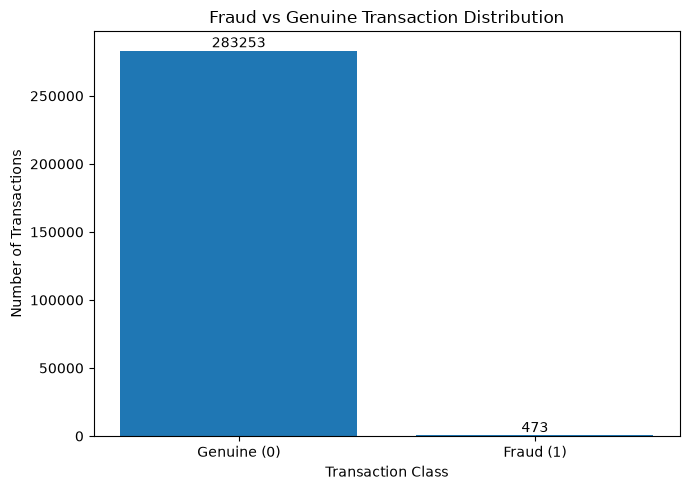

In [27]:
import matplotlib.pyplot as plt

# Count genuine and fraudulent transactions
class_counts = df["Class"].value_counts().sort_index()

# Create fraud distribution chart
plt.figure(figsize=(7, 5))
plt.bar(["Genuine (0)", "Fraud (1)"], class_counts.values)

plt.title("Fraud vs Genuine Transaction Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

# Add values on top of bars
for i, value in enumerate(class_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()

# Save visualization
plt.savefig("visualizations/fraud_distribution.png", dpi=300)

plt.show()

In [28]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data shape: (226980, 30)
Testing data shape: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [29]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nData types:")
print(X_train.dtypes.value_counts())

print("\nX_train shape:", X_train.shape)

Missing values in X_train:
0

Data types:
float64    30
Name: count, dtype: int64

X_train shape: (226980, 30)


In [30]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [31]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [32]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

lr_param_grid = {
    "smote__k_neighbors": [3, 5],
    "model__C": [0.1, 1, 10],
    "model__solver": ["lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Logistic Regression GridSearchCV created successfully.")

Logistic Regression GridSearchCV created successfully.


In [33]:
lr_grid.fit(X_train, y_train)

print("Logistic Regression tuning completed.")
print("\nBest Parameters:")
print(lr_grid.best_params_)

print("\nBest ROC-AUC:")
print(lr_grid.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Logistic Regression tuning completed.

Best Parameters:
{'model__C': 0.1, 'model__solver': 'lbfgs', 'smote__k_neighbors': 3}

Best ROC-AUC:
0.9814987750299771


In [34]:
rf_param_grid = {
    "smote__k_neighbors": [5],
    "model__n_estimators": [100],
    "model__max_depth": [None, 10]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Random Forest GridSearchCV created successfully.")

Random Forest GridSearchCV created successfully.


In [35]:
rf_grid.fit(X_train, y_train)

print("Random Forest tuning completed.")
print("\nBest Parameters:")
print(rf_grid.best_params_)

print("\nBest ROC-AUC:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


Random Forest tuning completed.

Best Parameters:
{'model__max_depth': 10, 'model__n_estimators': 100, 'smote__k_neighbors': 5}

Best ROC-AUC:
0.9811536037664043


In [36]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

# Best models
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predictions
lr_pred = best_lr.predict(X_test)
rf_pred = best_rf.predict(X_test)

# Probability scores
lr_prob = best_lr.predict_proba(X_test)[:, 1]
rf_prob = best_rf.predict_proba(X_test)[:, 1]

# Metrics
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_prob)

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("LOGISTIC REGRESSION")
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("ROC-AUC:", lr_roc_auc)

print("\nRANDOM FOREST")
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("ROC-AUC:", rf_roc_auc)

LOGISTIC REGRESSION
Precision: 0.052798982188295165
Recall: 0.8736842105263158
ROC-AUC: 0.9636732384526125

RANDOM FOREST
Precision: 0.6015625
Recall: 0.8105263157894737
ROC-AUC: 0.9733108255626091


<Figure size 600x500 with 0 Axes>

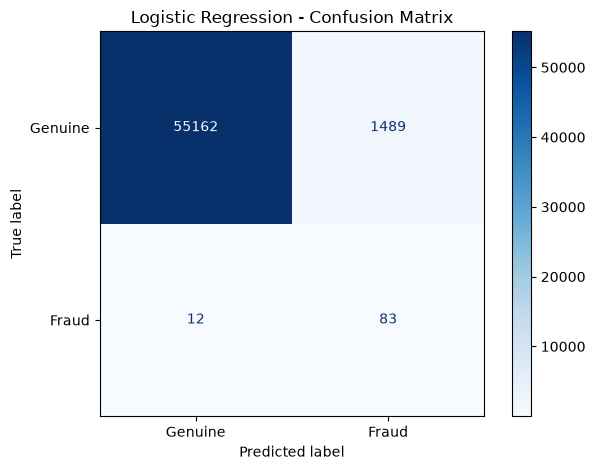

<Figure size 600x500 with 0 Axes>

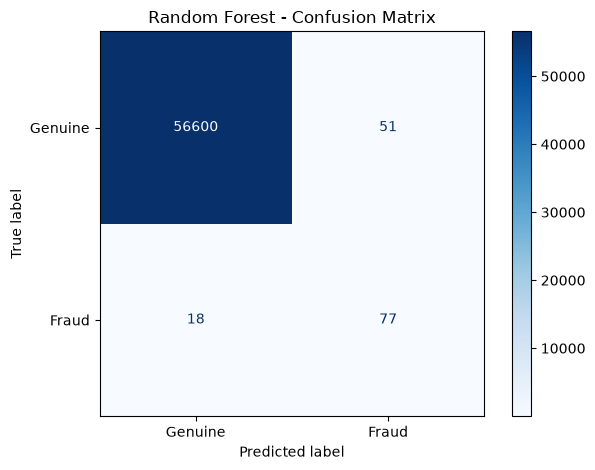

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression Confusion Matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Genuine", "Fraud"],
    cmap="Blues"
)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.savefig("visualizations/confusion_matrix_lr.png", dpi=300)
plt.show()

# Random Forest Confusion Matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Genuine", "Fraud"],
    cmap="Blues"
)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.savefig("visualizations/confusion_matrix_rf.png", dpi=300)
plt.show()

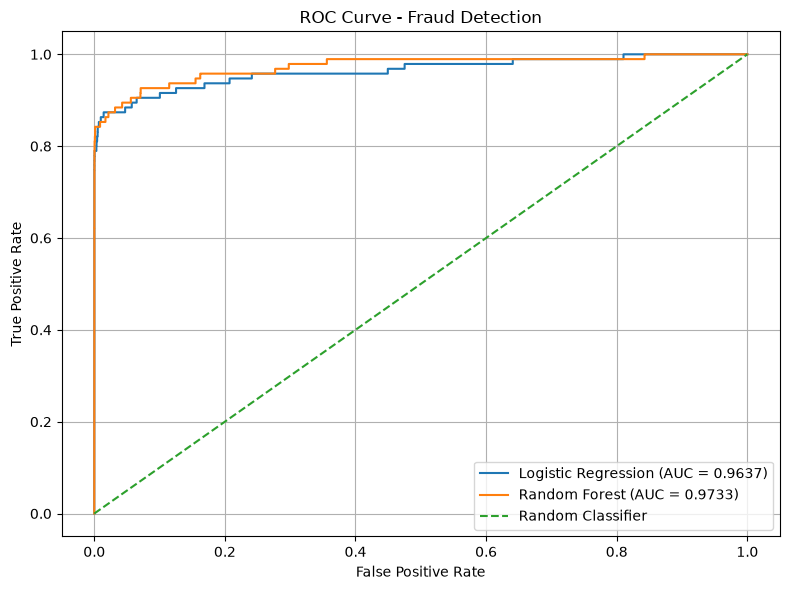

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - Fraud Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("visualizations/roc_curve.png", dpi=300)
plt.show()

In [39]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
    ]
})

print(results)

results.to_csv("output/model_results.csv", index=False)

                 Model  Precision    Recall   ROC-AUC
0  Logistic Regression   0.052799  0.873684  0.963673
1        Random Forest   0.601562  0.810526  0.973311


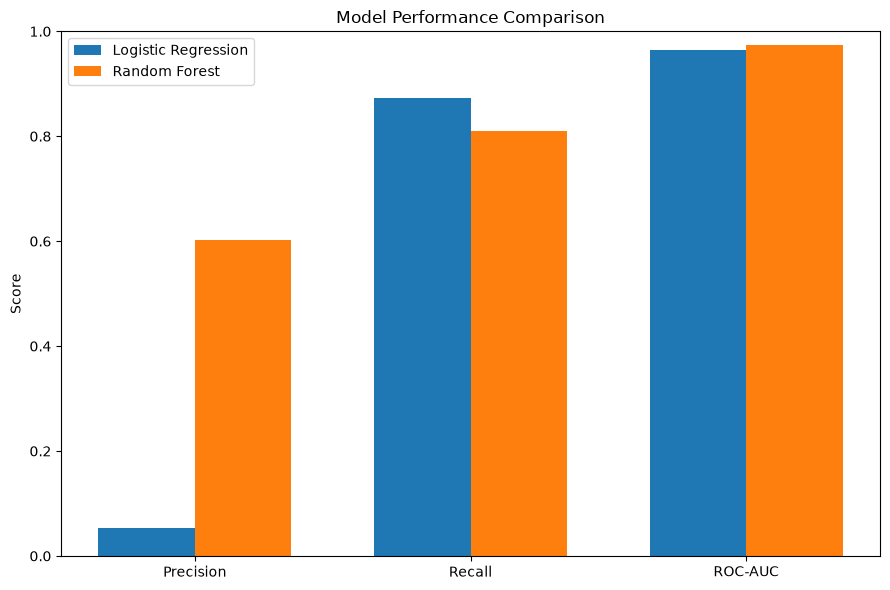

In [40]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "ROC-AUC"]

lr_values = [
    lr_precision,
    lr_recall,
    lr_roc_auc
]

rf_values = [
    rf_precision,
    rf_recall,
    rf_roc_auc
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(x - width/2, lr_values, width, label="Logistic Regression")
plt.bar(x + width/2, rf_values, width, label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("visualizations/model_comparison.png", dpi=300)
plt.show()

In [41]:
# Get the trained Random Forest model
rf_model = best_rf.named_steps["model"]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

# Save full feature importance
feature_importance.to_csv(
    "output/feature_importance.csv",
    index=False
)

   Feature  Importance
14     V14    0.236051
10     V10    0.130879
12     V12    0.114147
17     V17    0.098214
4       V4    0.096251
3       V3    0.072634
11     V11    0.056355
16     V16    0.039615
2       V2    0.038789
9       V9    0.027436


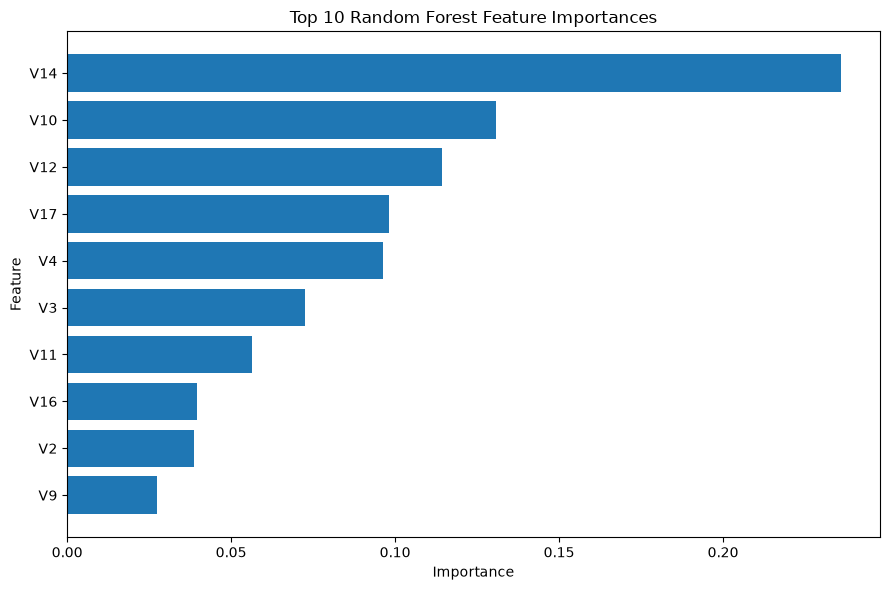

In [42]:
top_features = feature_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(
    "visualizations/feature_importance.png",
    dpi=300
)
plt.show()

In [43]:
predictions = pd.DataFrame({
    "Actual_Class": y_test.values,
    "Logistic_Regression_Prediction": lr_pred,
    "Logistic_Regression_Probability": lr_prob,
    "Random_Forest_Prediction": rf_pred,
    "Random_Forest_Probability": rf_prob
})

predictions.to_csv(
    "output/model_predictions.csv",
    index=False
)

print("Model predictions saved successfully.")
print("Rows saved:", len(predictions))

Model predictions saved successfully.
Rows saved: 56746


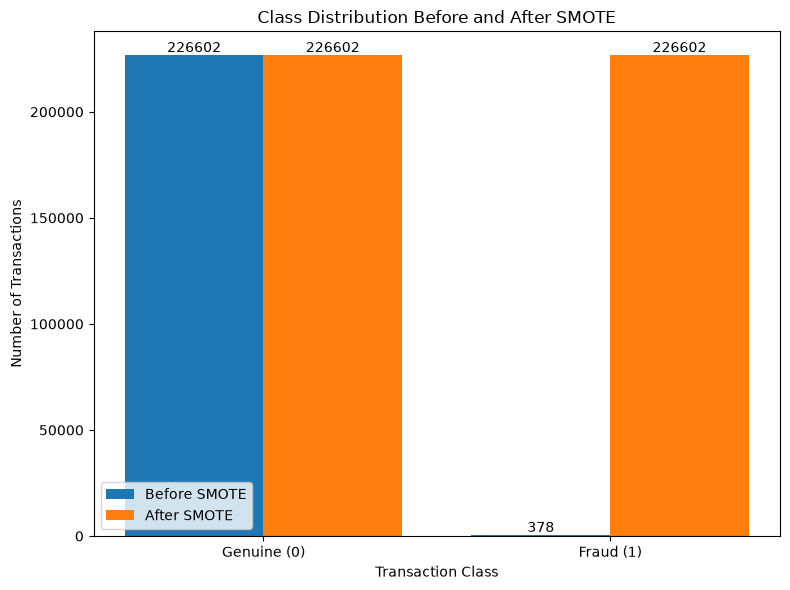

In [44]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# SMOTE for visualization only
smote_visual = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote_visual.fit_resample(X_train, y_train)

# Class counts before and after SMOTE
before_counts = y_train.value_counts().sort_index()
after_counts = y_train_smote.value_counts().sort_index()

# Plot
labels = ["Genuine (0)", "Fraud (1)"]
x = range(len(labels))

plt.figure(figsize=(8, 6))

plt.bar(
    [i - 0.2 for i in x],
    before_counts.values,
    width=0.4,
    label="Before SMOTE"
)

plt.bar(
    [i + 0.2 for i in x],
    after_counts.values,
    width=0.4,
    label="After SMOTE"
)

plt.xticks(list(x), labels)
plt.ylabel("Number of Transactions")
plt.xlabel("Transaction Class")
plt.title("Class Distribution Before and After SMOTE")
plt.legend()

for i, value in enumerate(before_counts.values):
    plt.text(i - 0.2, value, str(value), ha="center", va="bottom")

for i, value in enumerate(after_counts.values):
    plt.text(i + 0.2, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("visualizations/smote_distribution.png", dpi=300)
plt.show()

In [45]:
# Save GridSearchCV results

lr_cv_results = pd.DataFrame(lr_grid.cv_results_)
rf_cv_results = pd.DataFrame(rf_grid.cv_results_)

lr_cv_results.to_csv(
    "output/logistic_regression_gridsearch_results.csv",
    index=False
)

rf_cv_results.to_csv(
    "output/random_forest_gridsearch_results.csv",
    index=False
)

print("GridSearchCV results saved successfully.")

GridSearchCV results saved successfully.
